# Semana 10 · Adaptación de la Sesión 2 a PENGWIN

Referencia: `C:/Descargas3/Segmentacion_Sesion2_UNetPP_MaskRCNN_YOLO_SAM_Completo .ipynb`, secciones 4.1, 5, 6.2 y 9.

Implementación propia inspirada en conexiones encoder–decoder y supervisión profunda. **No es U-Net++ completa**: se usan sumas tras proyección a 8 canales para mantener el decoder ligero. Se conserva CBAM9, grid y NMS propios. SAM permanece como comparación separada.

El entrenamiento usa 560 cortes de 70 pacientes; validación, 120 cortes de 15 pacientes. Ningún resultado de mascotas/peatones se considera un resultado PENGWIN. Uso exclusivamente académico; sin validación clínica.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import matplotlib.pyplot as plt
RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ))
from pengwin.fragmentos_sesion2 import objetivos_fragmentos
OUT = RAIZ / 'salidas/sesion2'
print('Proyecto:', RAIZ)
print('Resultados disponibles:', (OUT/'comparacion_val.json').exists())

Proyecto: C:\Users\Asus\.codex\.chatgpt-projects\g-p-6a7924f5f0c881918894fd3001414af6\.revision-oct08
Resultados disponibles: True


## 1. Región anatómica e instancia son conceptos distintos

Cada valor 1–30 identifica un fragmento dentro de un hueso. Se conservan máscaras individuales `[N,H,W]`, sus IDs y sus clases anatómicas. Los objetivos auxiliares son interfaces entre fragmentos e interiores normalizados por fragmento; no dependen de cómo se numeren.

La figura siguiente usa un corte real de validación. Los colores de IDs son identificadores, no probabilidades.

Caso 002, corte 192 | IDs: [ 1 11 21] | clases: [1 2 3]


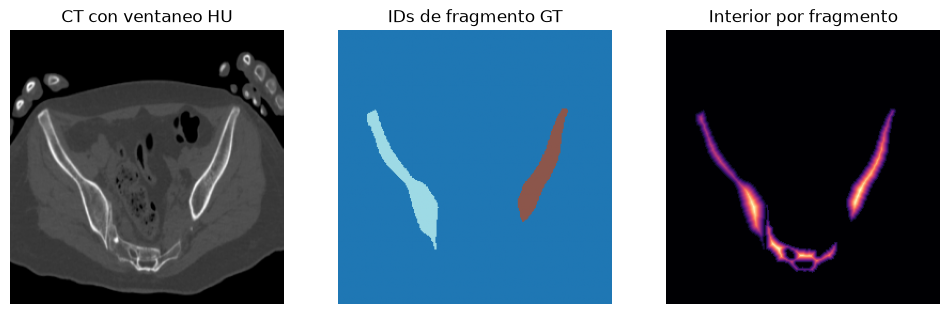

In [2]:
with np.load(RAIZ/'salidas/revision_oct08/datos/002.npz') as a:
    image = a['images'][4].copy()
    ids = a['instances'][4].copy()
    z = int(a['z'][4])
target = objetivos_fragmentos(ids)
print('Caso 002, corte', z, '| IDs:', target['ids'], '| clases:', target['labels'])
fig, ax = plt.subplots(1,3,figsize=(12,4))
ax[0].imshow(image,cmap='gray'); ax[0].set_title('CT con ventaneo HU')
ax[1].imshow(ids,cmap='tab20'); ax[1].set_title('IDs de fragmento GT')
ax[2].imshow(target['interiores'],cmap='magma',vmin=0,vmax=1); ax[2].set_title('Interior por fragmento')
for a in ax: a.axis('off')
plt.show()

## 2. Comparación controlada en validación

Ambas variantes se entrenan desde cero durante seis épocas con el mismo muestreo y split. Se selecciona cada checkpoint según la media de mAP50 y Dice semántico de validación. El cambio combina skips, supervisión profunda e interiores: no es una ablación de cada componente.

Un Dice alto por región no prueba que todos sus fragmentos estén separados. Revisar también Dice por instancia, omisiones y predicciones adicionales.

previo {
  "detection": {
    "mAP50": 0.44815335143178964,
    "mAP50_95": 0.13603749898431042,
    "per_class": {
      "0": {
        "gt": 52,
        "ap50": 0.17298508422270797,
        "ap50_95": 0.03333357455139633
      },
      "1": {
        "gt": 77,
        "ap50": 0.527152823012514,
        "ap50_95": 0.18037698748707517
      },
      "2": {
        "gt": 77,
        "ap50": 0.6443221470601468,
        "ap50_95": 0.1944019349144598
      }
    },
    "mean_gt_iou_at_conf025": 0.5192403994680935,
    "definition": "AP 101 puntos, IoU 0.50:0.05:0.95, NMS propio, sin filtros COCO por área"
  },
  "classification": {
    "per_class": [
      {
        "class": 0,
        "f1": 0.48,
        "auc": 0.9066742081447964,
        "tp": 18,
        "fp": 5,
        "fn": 34,
        "tn": 63
      },
      {
        "class": 1,
        "f1": 0.9261744966442953,
        "auc": 0.974025974025974,
        "tp": 69,
        "fp": 3,
        "fn": 8,
        "tn": 40
      },
      {
 

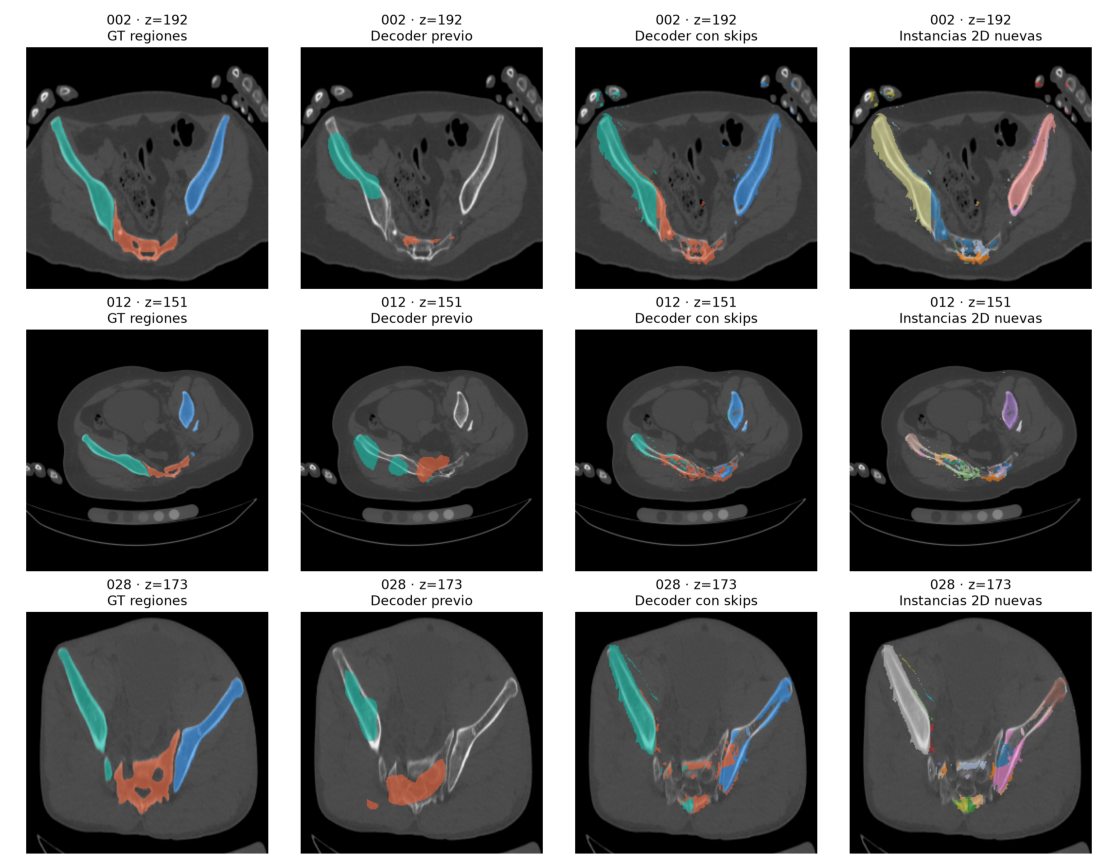

In [3]:
comparison=json.loads((OUT/'comparacion_val.json').read_text(encoding='utf-8'))
for name,metrics in comparison['metrics'].items():
    print(name, json.dumps(metrics,indent=2,ensure_ascii=False))
plt.figure(figsize=(15,11));plt.imshow(plt.imread(OUT/'comparacion_visual.png'));plt.axis('off');plt.show()

## 3. Reconstrucción 3D y distancia

La inferencia recorre todos los cortes contiguos, aplica cajas propias tras NMS y reconstruye instancias con watershed a partir de interiores y bordes aprendidos. Se conserva el espacio físico al redimensionar. La EDT aproxima distancias entre centros de vóxeles; el contacto 26 se reporta aparte.

Las distancias se comparan únicamente cuando tanto el fragmento como el principal tienen correspondencia GT con IoU ≥ 0,5. Sin correspondencia no se informa error cero.

In [4]:
for folder in ('volumenes', 'volumenes_filtrado'):
    summary=OUT/folder/'002/resumen.json'
    print(folder, summary.read_text(encoding='utf-8') if summary.exists() else 'Resultado aún no disponible.')
calibration=OUT/'calibracion_instancias_2d.json'
if calibration.exists(): print(calibration.read_text(encoding='utf-8'))

volumenes {
  "case": "002",
  "split": "val",
  "checkpoint_sha256": "ec2778e3e880d9ae1e3b29d5ccd12a23f0e42526db42d1d6a597ed471b55f4e3",
  "epoch": 6,
  "slices_contiguous": 337,
  "size_xyz": [
    256,
    256,
    337
  ],
  "spacing_xyz": [
    1.3296966552734375,
    0.88861083984375,
    0.800000011920929
  ],
  "origin": [
    -189.66439056396484,
    -165.40306091308594,
    -725.4089965820312
  ],
  "direction": [
    1.0,
    0.0,
    0.0,
    0.0,
    1.0,
    0.0,
    0.0,
    0.0,
    1.0
  ],
  "device": "cpu",
  "postprocessing": {
    "conf": 0.25,
    "nms": 0.4,
    "boundary": 0.5,
    "interior": 0.5
  },
  "latency_mean_ms": 32.99088011859696,
  "latency_median_ms": 32.821200002217665,
  "latency_scope": "forward+decode+NMS+semantic gating+transfer to CPU, 3 warmups; excluye lectura, resize y watershed 3D",
  "distance_definition": "EDT entre centros de voxeles de superficie, mm; aproximación discreta, no distancia exacta entre caras",
  "instance_method": "waters

## 4. Reproducir desde la raíz del proyecto

```powershell
$cfgPengwin = Get-Content config_datos.local.json -Raw | ConvertFrom-Json
& $cfgPengwin.python scripts/preparar_entrenamiento.py
& $cfgPengwin.python scripts/entrenar_sesion2.py --epochs 6
& $cfgPengwin.python scripts/evaluar_sesion2.py
& $cfgPengwin.python scripts/inferir_sesion2_3d.py --case 002 --compare-gt
```

Para ampliar un entrenamiento existente, usar `--resume` y más épocas, sin ajustar con test. No ejecutar el entrenamiento de nuevo sobre la misma salida sin reanudación. Las inferencias no sobrescriben resultados: seleccionar otra carpeta con `--output`.

Limitaciones: ocho cortes por paciente para entrenar, imágenes reducidas a 256, bordes/interiores aprendidos en 2D, posprocesamiento 3D pendiente de calibración más amplia. El notebook del profesor es referencia, no sustituye las restricciones del enunciado.